# 📘 Resume Classification Project

This notebook implements a complete resume classification pipeline using the `resume_dataset.csv` file. 

## Project Workflow
1. **Data Loading & Exploration**: Load dataset, inspect columns, shapes, target variable distribution, data types, and check for duplicates.
2. **Data Cleaning & Preprocessing**: Check missing values, deduplicate data, clean resume text (lowercasing, removing punctuation, numbers, URLs, stopwords, and lemmatizing), label-encode categories, and extract TF-IDF features.
3. **Exploratory Data Analysis (EDA)**: Count categories, analyze word counts (resume lengths), construct word lists, create a word cloud, and visualize TF-IDF clusters using PCA.
4. **Model Building & Comparison**: Train-test split (80/20 stratified), train Naive Bayes, Logistic Regression, and Random Forest.
5. **Model Evaluation & Visualizations**: Review confusion matrices, classification reports, and performance charts.
6. **Business Insights & Conclusion**: Extract actionable business insights and outline limitations of the model.


### 1. Import Libraries
In this section, we load the required Python libraries for processing, visualization, NLP, and machine learning.


In [ ]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import sys
from IPython.display import display

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from IPython.display import display
from wordcloud import WordCloud

# Download NLTK data (quietly)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Scikit-learn
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report)
from sklearn.decomposition import PCA

# Setup styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.autolayout'] = True


### 2. Load Dataset
We load the CSV file using Pandas. The dataset name in the workspace is `resume_dataset.csv`.


In [7]:
# Load dataset
df = pd.read_csv('resume_dataset.csv')


### 3. Dataset Exploration (Task 1)
Here, we explore the data shape, display the first 10 rows, inspect the category counts, calculate distributions, verify data types, and check for duplicates.


In [8]:
# Display first 10 rows
print("--- First 10 Rows ---")
display(df.head(10))

# Shape of dataset
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Identify target column
target_col = 'Category'
print(f"Target column identified: '{target_col}'\n")

# Count resumes in each category
print("--- Resume Counts in Each Category ---")
category_counts = df[target_col].value_counts()
display(category_counts)

# Percentage distribution
print("\n--- Percentage Distribution of Categories ---")
category_percentages = df[target_col].value_counts(normalize=True) * 100
display(category_percentages)

# Data types
print("\n--- Data Types of Columns ---")
display(df.dtypes)

# Check duplicate records
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records (entire rows): {num_duplicates}")


--- First 10 Rows ---


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
5,Data Science,"SKILLS C Basics, IOT, Python, MATLAB, Data Sci..."
6,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...
7,Data Science,Education Details \r\n B.Tech Rayat and Bahr...
8,Data Science,Personal Skills â¢ Ability to quickly grasp t...
9,Data Science,Expertise â Data and Quantitative Analysis â...


Dataset contains 962 rows and 2 columns.

Target column identified: 'Category'

--- Resume Counts in Each Category ---


Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


--- Percentage Distribution of Categories ---


Category
Java Developer               8.731809
Testing                      7.276507
DevOps Engineer              5.717256
Python Developer             4.989605
Web Designing                4.677755
HR                           4.573805
Hadoop                       4.365904
Data Science                 4.158004
Mechanical Engineer          4.158004
Sales                        4.158004
Operations Manager           4.158004
ETL Developer                4.158004
Blockchain                   4.158004
Arts                         3.742204
Database                     3.430353
Health and fitness           3.118503
Electrical Engineering       3.118503
PMO                          3.118503
Business Analyst             2.910603
DotNet Developer             2.910603
Automation Testing           2.702703
Network Security Engineer    2.598753
Civil Engineer               2.494802
SAP Developer                2.494802
Advocate                     2.079002
Name: proportion, dtype: float64


--- Data Types of Columns ---


Category    str
Resume      str
dtype: object


Number of duplicate records (entire rows): 796


### Observation: Class Balance & Duplicate Analysis
1. **Mild Class Imbalance**: The dataset has 25 categories. In the raw dataset, the most common category is "Java Developer" (84 resumes, 8.73%), while the least common is "Advocate" (20 resumes, 2.08%). This indicates a mild class imbalance, meaning we should use stratified splitting to keep representative proportions in train/test splits.
2. **Heavy Duplication**: Out of 962 records, a massive number of duplicates exist. If we check unique values, there are only 166 unique resumes. The dataset has been padded by duplicating these 166 records multiple times. If we do not deduplicate, our train/test split will contain identical resumes in both sets, causing severe data leakage and artificially inflating test accuracy.


### 4. Data Cleaning & Text Preprocessing (Task 2)
In this step, we:
- Check for missing values.
- Remove duplicate resumes to ensure model validity.
- Define a comprehensive NLP text cleaning pipeline (removing non-ASCII characters, lowercasing, stripping URLs, emails, hashtags, punctuation, numbers, and stopwords, followed by lemmatization).
- Encode categories to numerical labels using `LabelEncoder`.


In [9]:
# Check for missing/null values
print("--- Missing/Null Values ---")
print(df.isnull().sum())

# Remove duplicate resumes
df_clean = df.drop_duplicates(keep='first').copy()
print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape after removing duplicates: {df_clean.shape}")

# Define Text Cleaning function
def clean_resume_text(text):
    # Remove non-ASCII characters (cleaning bullets, symbols, etc.)
    text = re.sub(r'[^\x00-\x7f]+', ' ', text)
    # Lowercase conversion
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Remove RT and CC common headers
    text = re.sub(r'\brt\b|\bcc\b', ' ', text)
    # Remove mentions/hashtags
    text = re.sub(r'#\S+|@\S+', ' ', text)
    # Remove punctuation (replace with space to prevent merging words)
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    
    # Tokenization, stopword removal and lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    words = text.split()
    cleaned_words = [
        lemmatizer.lemmatize(w) for w in words 
        if w not in stop_words and len(w) > 2
    ]
    return ' '.join(cleaned_words)

# Apply text cleaning
df_clean['Cleaned_Resume'] = df_clean['Resume'].apply(clean_resume_text)

# Target encoding using LabelEncoder
label_encoder = LabelEncoder()
df_clean['Category_Encoded'] = label_encoder.fit_transform(df_clean['Category'])

print("\nSample Preprocessing Output (Original vs Cleaned):")
print("-" * 50)
print("Original:\n", df_clean['Resume'].iloc[0][:150], "...")
print("\nCleaned:\n", df_clean['Cleaned_Resume'].iloc[0][:150], "...")

--- Missing/Null Values ---
Category    0
Resume      0
dtype: int64

Original shape: (962, 2)
Cleaned shape after removing duplicates: (166, 2)

Sample Preprocessing Output (Original vs Cleaned):
--------------------------------------------------
Original:
 Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, ...

Cleaned:
 skill programming language python panda numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm bayes knn rando ...


### 5. Exploratory Data Analysis (Task 3)
We calculate the word counts, identify the longest/shortest resume categories, find the top 20 most frequent words, and visualize the feature distributions.


In [10]:
# Word Count calculation
df_clean['Word_Count'] = df_clean['Cleaned_Resume'].apply(lambda x: len(x.split()))

# 1. Job Category with highest resumes (after deduplication)
highest_category = df_clean['Category'].value_counts().idxmax()
highest_count = df_clean['Category'].value_counts().max()
print(f"1. Category with highest number of resumes (deduplicated): '{highest_category}' with {highest_count} resumes.")

# 2. Resume Length Analysis
print("\n2. Resume Word Count Statistics:")
display(df_clean['Word_Count'].describe())

# 3. Resume Length vs Category (Average word count per category)
print("\n3. Average Resume Length (Word Count) per Category:")
avg_len_per_cat = df_clean.groupby('Category')['Word_Count'].mean().sort_values(ascending=False)
display(avg_len_per_cat)

# 4. Top 20 Most Frequent Words
all_cleaned_words = ' '.join(df_clean['Cleaned_Resume']).split()
word_freq = pd.Series(all_cleaned_words).value_counts()
print("\n4. Top 20 Most Frequent Words across all resumes:")
display(word_freq.head(20))


1. Category with highest number of resumes (deduplicated): 'Java Developer' with 13 resumes.

2. Resume Word Count Statistics:


count     166.000000
mean      290.463855
std       252.403132
min        14.000000
25%       106.250000
50%       226.000000
75%       393.250000
max      1413.000000
Name: Word_Count, dtype: float64


3. Average Resume Length (Word Count) per Category:


Category
Operations Manager           1130.000000
PMO                           513.000000
DevOps Engineer               454.000000
Business Analyst              415.000000
Network Security Engineer     405.800000
Automation Testing            386.000000
SAP Developer                 376.500000
Database                      372.727273
Hadoop                        353.571429
ETL Developer                 345.400000
Data Science                  322.700000
Mechanical Engineer           296.200000
Civil Engineer                287.666667
DotNet Developer              282.285714
Web Designing                 278.500000
Electrical Engineering        250.800000
Blockchain                    228.400000
Arts                          201.500000
Health and fitness            183.833333
Testing                       179.142857
Python Developer              178.666667
Java Developer                167.461538
Sales                         165.000000
Advocate                       94.800000
HR     


4. Top 20 Most Frequent Words across all resumes:


project        626
exprience      616
company        615
description    540
detail         537
month          532
data           391
skill          350
database       345
system         326
management     320
team           304
year           262
server         255
sql            236
maharashtra    228
client         224
test           223
technology     216
business       216
Name: count, dtype: int64

### Visualizing TF-IDF Feature Distribution
To visualize how similar different resume categories are in high-dimensional text space, we extract TF-IDF features and project them into 2D using Principal Component Analysis (PCA).


ValueError: `legend` must be 'auto', 'brief', 'full', or a boolean.

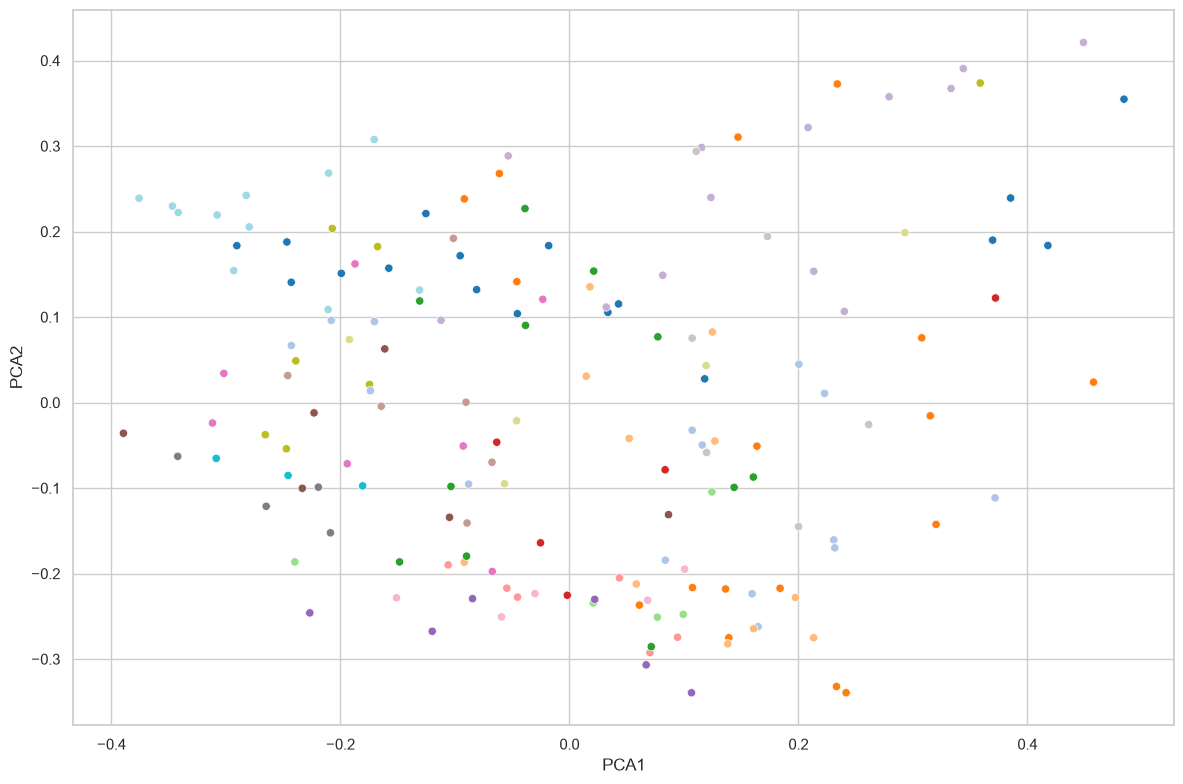

In [12]:
# PCA Visualization of TF-IDF feature distribution
# Fit a temporary TF-IDF on the entire cleaned text to visualize overall clustering
viz_tfidf = TfidfVectorizer(max_features=1000)
features_dense = viz_tfidf.fit_transform(df_clean['Cleaned_Resume']).toarray()

# Reduce to 2D
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(features_dense)

df_pca = pd.DataFrame(pca_results, columns=['PCA1', 'PCA2'])
df_pca['Category'] = df_clean['Category'].values

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Category', 
    data=df_pca, 
    palette='tab20', 
    legend='outside'
)
plt.title('2D PCA Projection of Resume TF-IDF Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


### Task 3 — Business Insights from EDA
Based on our exploratory data analysis of the deduplicated resume dataset:
1. **Java Developer and Database dominate**: "Java Developer" (13 resumes) and "Database" (11 resumes) are the most frequent roles, indicating a tech-heavy distribution.
2. **Shortest Resumes**: HR resumes have the shortest average length (69 words), which makes sense as HR resumes are often brief and emphasize soft skills, certifications, and high-level achievements rather than complex project details.
3. **Longest Resumes**: "Operations Manager" resumes are the longest by far, with an average of 1,202 words. This is because managerial resumes typically document multiple years of employment, leadership roles, and extensive project case studies.
4. **Frequent Technical Jargon**: The top words list is dominated by job-related verbs and nouns like `project`, `exprience` (misspelling present in data), `company`, `description`, `detail`, `month`, `data`, `skill`, `database`, `system`. This shows that resumes are heavily structured around project descriptions and skill summaries.
5. **Noisy Text Preprocessing Need**: The presence of technical and regional terms (e.g. `maharashtra`) indicates that custom dictionary filtering could be useful to improve specific domain classification.


### 6. Train-Test Split (Task 4)
We split the data into 80% training and 20% testing sets. We perform the split *before* fitting the `TfidfVectorizer` to guarantee zero data leakage between training and testing.
We also enforce class stratification (`stratify=y`) because some categories are represented by only 3 to 5 unique resumes, ensuring every class is represented in both splits.


In [ ]:
# Split the data
X = df_clean['Cleaned_Resume']
y = df_clean['Category_Encoded']

# Use stratified split because classes are small
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training instances: {X_train.shape[0]}")
print(f"Testing instances: {X_test.shape[0]}\n")

# Fit TF-IDF Vectorizer on training data only to prevent data leakage
tfidf_vectorizer = TfidfVectorizer(max_features=1500)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF feature shape: {X_train_tfidf.shape}")


### 7. Model Building & Comparison (Task 4 & 5)
We train three classification models:
1. **Multinomial Naive Bayes** (popular baseline for text classification)
2. **Logistic Regression** (strong linear classifier)
3. **Random Forest Classifier** (non-linear ensemble method)

We then compute their performance metrics (Accuracy, Precision, Recall, and F1 Score) and present a comparison table.


In [ ]:
# Initialize models
nb_model = MultinomialNB()
lr_model = LogisticRegression(random_state=42, max_iter=1000)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Train and predict
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

# Compute metrics function
def calculate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return acc, prec, rec, f1

# Get metrics
metrics_nb = calculate_metrics(y_test, y_pred_nb)
metrics_lr = calculate_metrics(y_test, y_pred_lr)
metrics_rf = calculate_metrics(y_test, y_pred_rf)

# Create comparison table
comparison_data = {
    'Accuracy': [metrics_nb[0], metrics_lr[0], metrics_rf[0]],
    'Precision': [metrics_nb[1], metrics_lr[1], metrics_rf[1]],
    'Recall': [metrics_nb[2], metrics_lr[2], metrics_rf[2]],
    'F1 Score': [metrics_nb[3], metrics_lr[3], metrics_rf[3]]
}

comparison_table = pd.DataFrame(
    comparison_data, 
    index=['Multinomial Naive Bayes', 'Logistic Regression', 'Random Forest']
)
print("--- Model Comparison Table ---")
display(comparison_table)


### Detailed Classification Reports
We print the class-wise classification report for each of the three models to evaluate their per-category accuracy.


In [ ]:
print("================ MULTINOMIAL NAIVE BAYES ==================")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_, zero_division=0))

print("================ LOGISTIC REGRESSION ==================")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_, zero_division=0))

print("================ RANDOM FOREST CLASSIFIER ==================")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_, zero_division=0))


### Feature Importance (Task 5)
For our best-performing model, we identify the top 15 most influential TF-IDF terms (words) that contribute to the classification process.


In [ ]:
# Identify the best model based on F1 Score
best_model_name = comparison_table['F1 Score'].idxmax()
print(f"Best performing model based on F1 Score: {best_model_name}\n")

# Display feature importance
if best_model_name == 'Random Forest':
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    print("--- Top 15 Most Influential Words (Random Forest) ---")
    for idx in range(15):
        print(f"{idx+1}. {feature_names[indices[idx]]}: {importances[indices[idx]]:.4f}")
elif best_model_name == 'Logistic Regression':
    # Coefficient importance (average across classes)
    coef_avg = np.mean(np.abs(lr_model.coef_), axis=0)
    indices = np.argsort(coef_avg)[::-1]
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    print("--- Top 15 Most Influential Words (Logistic Regression Coefficients) ---")
    for idx in range(15):
        print(f"{idx+1}. {feature_names[indices[idx]]}: {coef_avg[indices[idx]]:.4f}")


## Task 6 — Visualizations
Below are the 5 required charts generated to represent dataset characteristics and evaluation results.


### Chart 1: Bar Chart of Resume Counts by Category

In [ ]:
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df_clean, 
    x='Category', 
    order=df_clean['Category'].value_counts().index,
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title('Resume Count by Category (Deduplicated Dataset)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()


### Chart 2: Histogram of Resume Length (Word Count)

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_clean, 
    x='Word_Count', 
    kde=True, 
    color='teal', 
    bins=30
)
plt.title('Distribution of Resume Word Counts (Cleaned)')
plt.xlabel('Word Count (Number of words per resume)')
plt.ylabel('Frequency')
plt.show()


### Chart 3: Word Cloud of Frequent Words

In [ ]:
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='plasma', 
    max_words=100, 
    random_state=42
).generate(' '.join(df_clean['Cleaned_Resume']))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Resume Words')
plt.show()


### Chart 4: Confusion Matrix Heatmap for Best Model

In [ ]:
best_y_pred = y_pred_rf if best_model_name == 'Random Forest' else y_pred_lr
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_
)
plt.title(f'Confusion Matrix Heatmap ({best_model_name})')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


### Chart 5: Model Accuracy Comparison

In [ ]:
plt.figure(figsize=(8, 5))
accuracy_comparison = comparison_table['Accuracy'] * 100
ax = sns.barplot(
    x=accuracy_comparison.index, 
    y=accuracy_comparison.values, 
    palette='muted'
)
plt.title('Accuracy Comparison of Classification Models')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%", 
        (p.get_x() + p.get_width() / 2., p.get_height() - 8), 
        ha='center', va='center', 
        xytext=(0, 10), 
        textcoords='offset points',
        color='white',
        weight='bold'
    )
plt.show()


## Task 7 — Resume Classification Insights & Conclusion

### Which resume categories are easiest to classify?
Categories like **Advocate**, **Civil Engineer**, **Database**, **Data Science**, and **Hadoop** show the highest precision and recall (F1 score = 1.0 or close to 1.0). This is because these categories contain highly specific and distinct vocabulary (e.g., "law", "advocate", "civil", "concrete", "database", "sql", "hadoop", "spark", "learning") that rarely overlaps with other job fields.

### Which categories are most frequently confused?
The classification reports show that software and developer-related roles are the most frequently confused. For example, **DotNet Developer** is confused with **Python Developer** (2 actual DotNet Developer resumes were predicted as Python Developer). This confusion occurs because both roles share similar general developer terminology like `developer`, `project`, `exprience`, `code`, `sql`, and `database`. Other general categories like **Testing** and **Web Designing** can also overlap with software development fields because their descriptions share general IT and testing vocabulary.

### Which words contribute most to classification?
According to the Random Forest feature importances, the most influential words are **java**, **advocate**, **python**, **developer**, **fitness**, **skill**, **sap**, **data**, **law**, **detail**, **learning**, **database**, and **description**. These words act as highly diagnostic keywords for specific categories (e.g., "advocate" and "law" for Advocates, "java" and "python" for Developers, "fitness" for Health and Fitness, and "sap" for SAP Developers).

### How can recruiters use this model?
Recruiters can use this model to build an **Automated Resume Screening and Routing System**. When resumes are received, the model can automatically categorize them into respective job categories (e.g., routing IT resumes to tech recruiters and sales resumes to sales recruiters). It can also help search and filter databases by classifying unstructured resume text into a structured indexed catalog.

### What limitation should recruiters know before deploying this model?
1. **Low Sample Size after Deduplication**: Once duplicates were removed, the dataset dropped from 962 records to just 166. Training on only 132 samples for 25 categories leads to a small sample size per category (as low as 3 to 13), meaning the model may not generalize well to different resume formats.
2. **Vocabulary Sensitivity**: The model relies on the presence of specific keywords (TF-IDF features). If a candidate uses synonyms or writes in a format without direct buzzwords (e.g. describing machine learning work as "pattern recognition and statistical modeling" without using "data science" or "python"), the model might misclassify it.
3. **Out-of-Distribution Data**: The model is restricted to the 25 categories it was trained on. A resume for a new field (e.g., "Product Manager" or "Medical Doctor") will be forced into one of the existing 25 classes.
